# Contagem de Parafusos — Pipeline Visual
Cada célula mostra o resultado de uma etapa do processamento.
Filtros aplicados: **área**, **solidez**, **aspecto** e **extent**.

In [17]:
# !pip install opencv-python-headless numpy matplotlib

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

CAMINHO_IMAGEM = 'img1.jpg'

# Parâmetros ajustáveis
BLUR_KERNEL  = (5, 5)
MORPH_KERNEL = (3, 3)
MORPH_ITER   = 2
AREA_MIN     = 200
AREA_MAX     = 50_000
MARGEM = 30  # pixels pra ignorar nas bordas
USAR_WATERSHED       = True
WATERSHED_DIST_LIMIAR = 0.3

# Filtros de forma
SOLIDEZ_MIN  = 0.35   # área / convex_hull  (formas ocas/irregulares ficam < 0.5)
ASPECTO_MIN  = 0.10   # largura/altura mínima (descarta traços finos demais)
ASPECTO_MAX  = 10.0   # largura/altura máxima
EXTENT_MIN   = 0.15   # área / bounding_rect (descarta formas que preenchem mal o bbox)

# Fechamento morfológico — preenche reflexos metálicos (buracos escuros pós-binarização)
# Aumente se parafusos ainda fragmentarem; reduza se parafusos adjacentes se fundirem
CLOSE_KERNEL = (9, 9)
CLOSE_ITER   = 1
# ──────────────────────────────────────────────────────────────────────

def mostrar(titulo, img, cmap=None):
    plt.figure(figsize=(7, 5))
    plt.imshow(img, cmap=cmap)
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def metricas_forma(contorno):
    """Retorna dicionário com área, solidez, aspecto e extent."""
    area      = cv2.contourArea(contorno)
    hull_area = cv2.contourArea(cv2.convexHull(contorno))
    solidez   = area / hull_area if hull_area > 0 else 0.0
    x, y, w, h = cv2.boundingRect(contorno)
    aspecto   = w / h if h > 0 else 0.0
    extent    = area / (w * h) if (w * h) > 0 else 0.0
    return dict(area=area, solidez=solidez, aspecto=aspecto, extent=extent, x=x, y=y, w=w, h=h)

def e_parafuso(m):
    """Retorna (aceito: bool, motivo_rejeicao: str)."""
    if not (AREA_MIN <= m['area'] <= AREA_MAX):
        return False, f"area={m['area']:.0f}"
    if m['solidez'] < SOLIDEZ_MIN:
        return False, f"solidez={m['solidez']:.2f}"
    if not (ASPECTO_MIN <= m['aspecto'] <= ASPECTO_MAX):
        return False, f"aspecto={m['aspecto']:.2f}"
    if m['extent'] < EXTENT_MIN:
        return False, f"extent={m['extent']:.2f}"
    return True, ""

def aplicar_watershed(limpa, imagem_bgr):
    """
    Separa objetos grudados via watershed.
    Retorna máscara binária com os objetos separados pelas bordas encontradas.
    """
    dist = cv2.distanceTransform(limpa, cv2.DIST_L2, 5)

    _, sure_fg = cv2.threshold(dist, WATERSHED_DIST_LIMIAR * dist.max(), 255, 0)
    sure_fg = sure_fg.astype(np.uint8)

    sure_bg = cv2.dilate(limpa, np.ones((3, 3), np.uint8), iterations=3)
    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1          # background = 1, objetos >= 2
    markers[unknown == 255] = 0    # região incerta = 0 (watershed preenche)

    img_ws = imagem_bgr.copy()
    markers_out = cv2.watershed(img_ws, markers)

    # Reconstrói máscara binária sem as bordas (-1) e sem background (1)
    mascara_ws = np.zeros_like(limpa)
    mascara_ws[markers_out > 1] = 255

    n_regioes = markers_out.max() - 1
    return mascara_ws, markers_out, n_regioes

## Etapa 0 — Carregar imagem

Resolução: 640x640 px


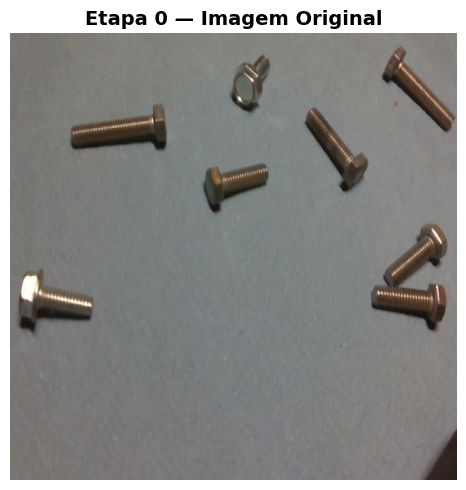

In [19]:
imagem_bgr = cv2.imread(CAMINHO_IMAGEM)
if imagem_bgr is None:
    raise FileNotFoundError(f'Imagem não encontrada: {CAMINHO_IMAGEM}')

imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)
print(f'Resolução: {imagem_bgr.shape[1]}x{imagem_bgr.shape[0]} px')
mostrar('Etapa 0 — Imagem Original', imagem_rgb)

## Etapa 1 — Escala de cinza

Range de valores: [10, 255]


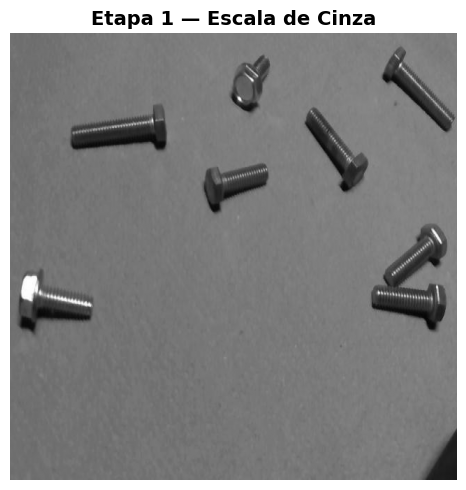

In [20]:
cinza = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)
print(f'Range de valores: [{cinza.min()}, {cinza.max()}]')
mostrar('Etapa 1 — Escala de Cinza', cinza, cmap='gray')

## Etapa 2 — Blur Gaussiano
Suaviza ruído antes da binarização.

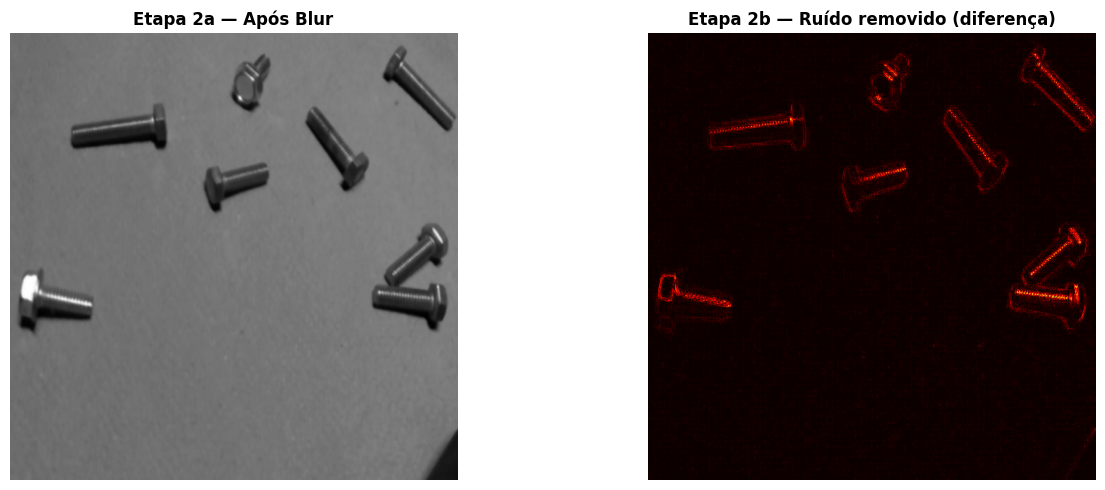

In [21]:
suavizada = cv2.GaussianBlur(cinza, BLUR_KERNEL, 0)
diff = cv2.absdiff(cinza, suavizada)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(suavizada, cmap='gray')
axes[0].set_title('Etapa 2a — Após Blur', fontweight='bold'); axes[0].axis('off')
axes[1].imshow(diff, cmap='hot')
axes[1].set_title('Etapa 2b — Ruído removido (diferença)', fontweight='bold'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## Etapa 3 — Binarização com ADAPTIVE_THRESH_GAUSSIAN_C
Fundo claro → `THRESH_BINARY_INV`: parafusos ficam **brancos**, fundo **preto**.

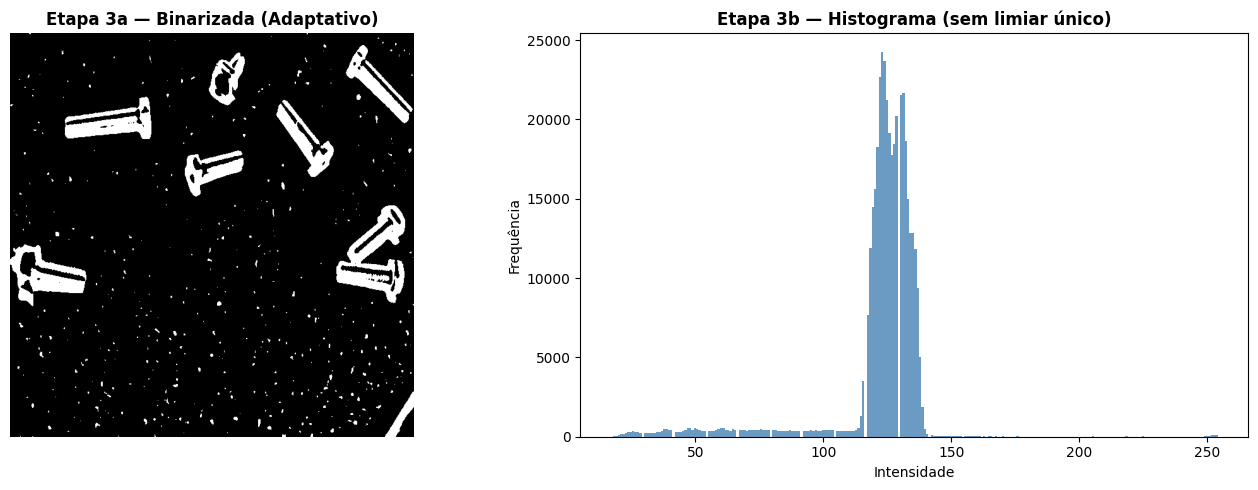

In [22]:
binaria = cv2.adaptiveThreshold(
    suavizada, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    51,  # tamanho do bloco
    4    # constante C
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(binaria, cmap='gray')
axes[0].set_title('Etapa 3a — Binarizada (Adaptativo)', fontweight='bold'); axes[0].axis('off')
axes[1].hist(suavizada.ravel(), bins=256, color='steelblue', alpha=0.8)
axes[1].set_title('Etapa 3b — Histograma (sem limiar único)', fontweight='bold')
axes[1].set_xlabel('Intensidade'); axes[1].set_ylabel('Frequência')
plt.tight_layout(); plt.show()

## 🧹 Etapa 4 — Morfologia: Close → Open
**Close** (dilata → erode): preenche reflexos metálicos que fragmentam o parafuso.  
**Open** (erode → dilata): remove pequenos pontos espúrios restantes.

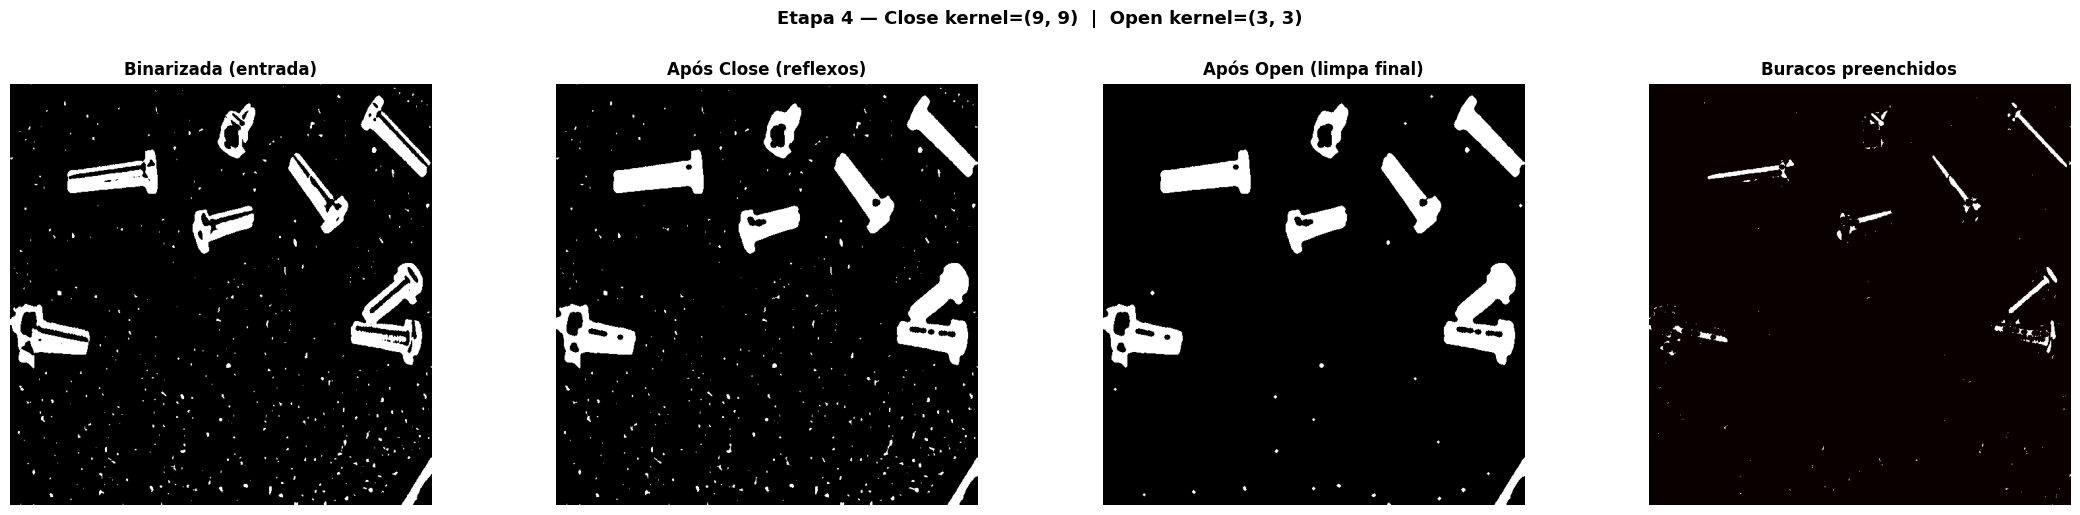

Pixels preenchidos pelo Close (reflexos): 5134
Pixels removidos  pelo Open  (ruído):     3201


In [23]:
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, CLOSE_KERNEL)
kernel_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, MORPH_KERNEL)

# Passo 4a — Close: fecha buracos escuros causados por reflexo metálico
fechada = cv2.morphologyEx(binaria, cv2.MORPH_CLOSE, kernel_close, iterations=CLOSE_ITER)

# Passo 4b — Open: elimina ruído residual pequeno
limpa   = cv2.morphologyEx(fechada, cv2.MORPH_OPEN,  kernel_open,  iterations=MORPH_ITER)

buracos_fechados = cv2.subtract(fechada, binaria)   # pixels que o Close adicionou
removidos        = cv2.subtract(fechada, limpa)     # pixels que o Open removeu

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(binaria,          cmap='gray'); axes[0].set_title('Binarizada (entrada)',    fontweight='bold'); axes[0].axis('off')
axes[1].imshow(fechada,          cmap='gray'); axes[1].set_title('Após Close (reflexos)',   fontweight='bold'); axes[1].axis('off')
axes[2].imshow(limpa,            cmap='gray'); axes[2].set_title('Após Open (limpa final)', fontweight='bold'); axes[2].axis('off')
axes[3].imshow(buracos_fechados, cmap='hot');  axes[3].set_title('Buracos preenchidos',     fontweight='bold'); axes[3].axis('off')
plt.suptitle(
    f'Etapa 4 — Close kernel={CLOSE_KERNEL}  |  Open kernel={MORPH_KERNEL}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout(); plt.show()

n_buracos = int(np.sum(buracos_fechados > 0))
n_ruido   = int(np.sum(removidos > 0))
print(f'Pixels preenchidos pelo Close (reflexos): {n_buracos}')
print(f'Pixels removidos  pelo Open  (ruído):     {n_ruido}')

## Etapa 4b — Watershed (opcional)

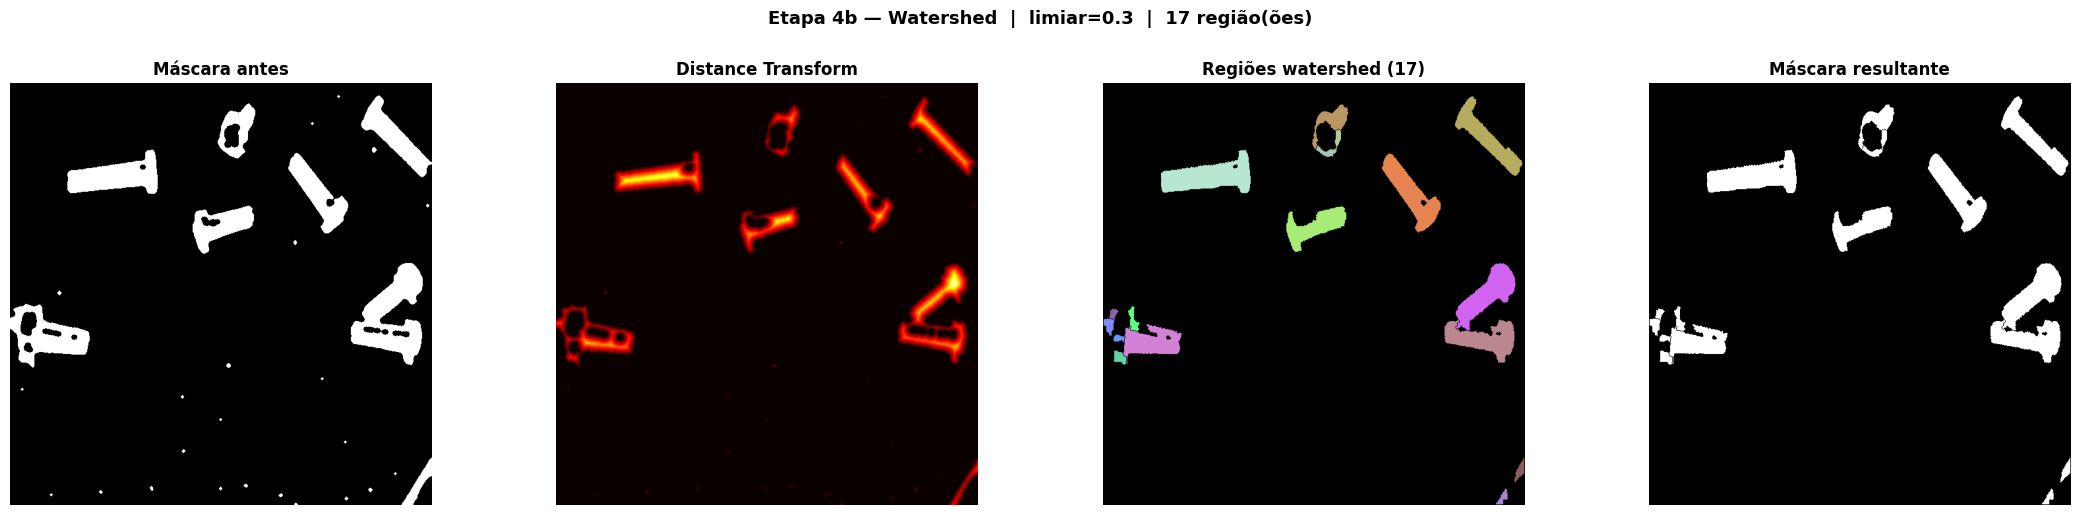

Watershed aplicado — 17 região(ões) encontrada(s)
Se ainda estiver grudando: aumente WATERSHED_DIST_LIMIAR (ex: 0.5)
Se fragmentou demais:      reduza  WATERSHED_DIST_LIMIAR (ex: 0.3)


In [24]:
# Ativado por USAR_WATERSHED = True nos parâmetros.
# Separa parafusos que se tocam ou se sobrepõem na máscara binária.

if USAR_WATERSHED:
    limpa_ws, markers_out, n_ws = aplicar_watershed(limpa, imagem_bgr)

    dist = cv2.distanceTransform(limpa, cv2.DIST_L2, 5)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    axes[0].imshow(limpa,    cmap='gray'); axes[0].set_title('Máscara antes',        fontweight='bold'); axes[0].axis('off')
    axes[1].imshow(dist,     cmap='hot');  axes[1].set_title('Distance Transform',   fontweight='bold'); axes[1].axis('off')

    # Visualiza regiões coloridas
    mapa_cores = np.zeros((*limpa.shape, 3), dtype=np.uint8)
    np.random.seed(42)
    for label in range(2, markers_out.max() + 1):
        cor = np.random.randint(80, 255, 3)
        mapa_cores[markers_out == label] = cor
    axes[2].imshow(mapa_cores); axes[2].set_title(f'Regiões watershed ({n_ws})', fontweight='bold'); axes[2].axis('off')
    axes[3].imshow(limpa_ws,  cmap='gray'); axes[3].set_title('Máscara resultante', fontweight='bold'); axes[3].axis('off')

    plt.suptitle(f'Etapa 4b — Watershed  |  limiar={WATERSHED_DIST_LIMIAR}  |  {n_ws} região(ões)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

    # Substitui máscara limpa pela versão separada pelo watershed
    limpa = limpa_ws
    print(f'Watershed aplicado — {n_ws} região(ões) encontrada(s)')
    print('Se ainda estiver grudando: aumente WATERSHED_DIST_LIMIAR (ex: 0.5)')
    print('Se fragmentou demais:      reduza  WATERSHED_DIST_LIMIAR (ex: 0.3)')
else:
    print('Watershed desativado (USAR_WATERSHED = False)')


## 🔍 Etapa 5 — Detecção de Contornos (brutos)
Todos os contornos antes de qualquer filtro.

In [25]:
#remove contornos 

h, w = limpa.shape
limpa[:MARGEM, :]  = 0  # topo
limpa[-MARGEM:, :] = 0  # baixo
limpa[:, :MARGEM]  = 0  # esquerda
limpa[:, -MARGEM:] = 0  # direita

Contornos brutos: 7
Área  — min: 2322  max: 6078  média: 3664 px²


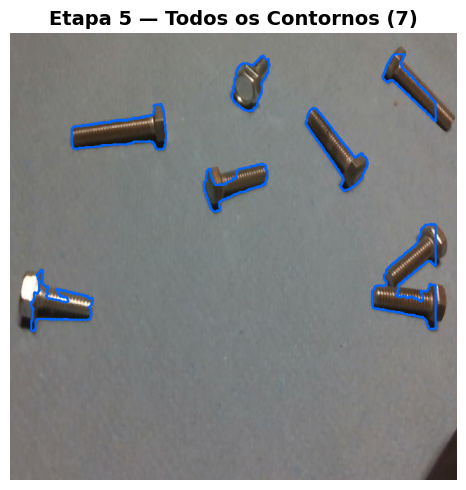

In [26]:
contornos, _ = cv2.findContours(limpa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Calcula métricas de todos
metricas = [metricas_forma(c) for c in contornos]
areas    = [m['area'] for m in metricas]

vis_todos = imagem_rgb.copy()
cv2.drawContours(vis_todos, contornos, -1, (0, 100, 255), 2)

print(f'Contornos brutos: {len(contornos)}')
if areas:
    print(f'Área  — min: {min(areas):.0f}  max: {max(areas):.0f}  média: {np.mean(areas):.0f} px²')
mostrar(f'Etapa 5 — Todos os Contornos ({len(contornos)})', vis_todos)

## Etapa 6 — Distribuição de Áreas
Use esse gráfico para calibrar `AREA_MIN` e `AREA_MAX`.

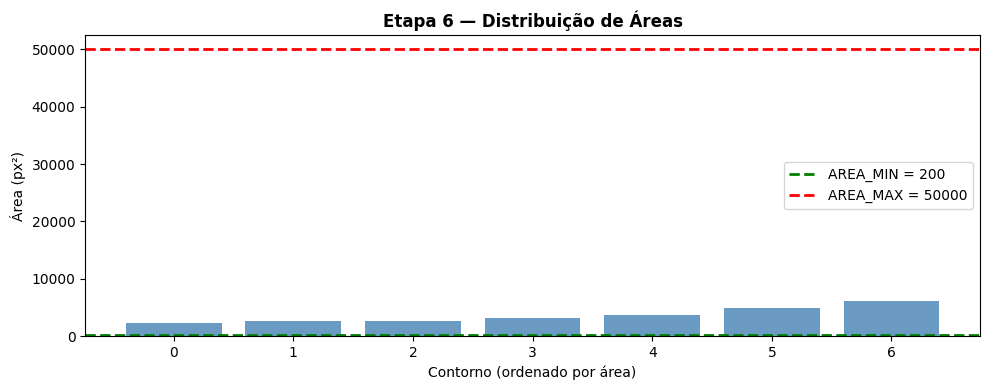

Contornos entre as linhas verde e vermelha passam no filtro de área.


In [27]:
if areas:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(areas)), sorted(areas), color='steelblue', alpha=0.8)
    ax.axhline(AREA_MIN, color='green', linewidth=2, linestyle='--', label=f'AREA_MIN = {AREA_MIN}')
    ax.axhline(AREA_MAX, color='red',   linewidth=2, linestyle='--', label=f'AREA_MAX = {AREA_MAX}')
    ax.set_title('Etapa 6 — Distribuição de Áreas', fontweight='bold')
    ax.set_xlabel('Contorno (ordenado por área)'); ax.set_ylabel('Área (px²)')
    ax.legend(); plt.tight_layout(); plt.show()
    print('Contornos entre as linhas verde e vermelha passam no filtro de área.')

## Etapa 7 — Filtros de Forma (solidez, aspecto, extent)
Métricas calculadas para cada contorno que passou no filtro de área.

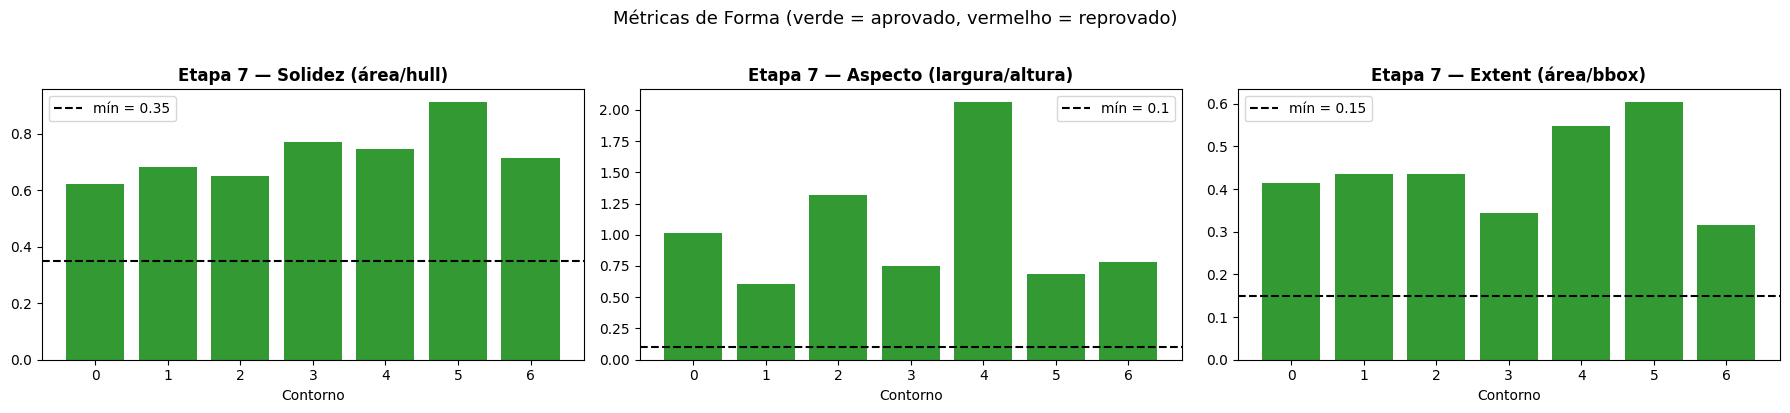

Candidatos (passaram na área): 7


In [28]:
# Filtra só os que passam no critério de área para inspecionar as métricas de forma
candidatos = [(c, m) for c, m in zip(contornos, metricas) if AREA_MIN <= m['area'] <= AREA_MAX]

if candidatos:
    solidez_vals = [m['solidez'] for _, m in candidatos]
    aspecto_vals = [m['aspecto'] for _, m in candidatos]
    extent_vals  = [m['extent']  for _, m in candidatos]
    idx          = range(len(candidatos))

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for ax, vals, limiar, nome, cor in [
        (axes[0], solidez_vals, SOLIDEZ_MIN, 'Solidez (área/hull)',         'steelblue'),
        (axes[1], aspecto_vals, ASPECTO_MIN, 'Aspecto (largura/altura)',     'darkorange'),
        (axes[2], extent_vals,  EXTENT_MIN,  'Extent (área/bbox)',           'mediumpurple'),
    ]:
        cores = ['green' if v >= limiar else 'red' for v in vals]
        ax.bar(idx, vals, color=cores, alpha=0.8)
        ax.axhline(limiar, color='black', linewidth=1.5, linestyle='--', label=f'mín = {limiar}')
        ax.set_title(f'Etapa 7 — {nome}', fontweight='bold')
        ax.set_xlabel('Contorno'); ax.legend()

    plt.suptitle('Métricas de Forma (verde = aprovado, vermelho = reprovado)', fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()
    print(f'Candidatos (passaram na área): {len(candidatos)}')
else:
    print('Nenhum contorno passou no filtro de área.')

## Etapa 8 — Resultado Final
Aplica todos os filtros (área + forma) e anota a imagem.

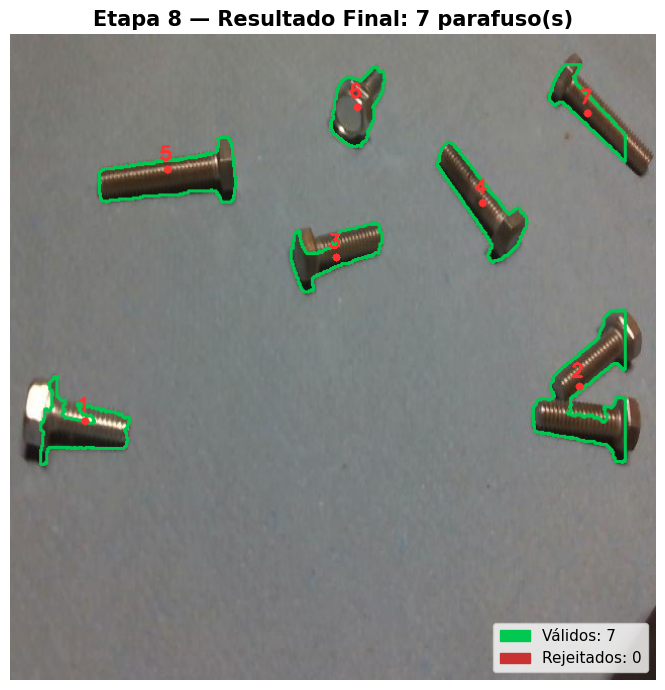

 TOTAL DE PARAFUSOS: 7


In [29]:
vis_final = imagem_rgb.copy()
validos, rejeitados_lista = [], []

for c, m in zip(contornos, metricas):
    ok, motivo = e_parafuso(m)
    if ok:
        validos.append((c, m))
        cv2.drawContours(vis_final, [c], -1, (0, 200, 80), 2)
        cx = m['x'] + m['w'] // 2
        cy = m['y'] + m['h'] // 2
        cv2.circle(vis_final, (cx, cy), 4, (255, 50, 50), -1)
        cv2.putText(vis_final, str(len(validos)), (cx - 8, cy - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 50, 50), 2)
    else:
        rejeitados_lista.append((c, m, motivo))
        cv2.drawContours(vis_final, [c], -1, (200, 50, 50), 1)
        # Mostra motivo da rejeição em vermelho
        cv2.putText(vis_final, motivo, (m['x'], max(m['y'] - 4, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (200, 50, 50), 1)

patch_ok  = mpatches.Patch(color=(0/255, 200/255, 80/255),  label=f'Válidos: {len(validos)}')
patch_bad = mpatches.Patch(color=(200/255, 50/255, 50/255), label=f'Rejeitados: {len(rejeitados_lista)}')

plt.figure(figsize=(9, 7))
plt.imshow(vis_final)
plt.title(f'Etapa 8 — Resultado Final: {len(validos)} parafuso(s)', fontsize=15, fontweight='bold')
plt.legend(handles=[patch_ok, patch_bad], loc='lower right', fontsize=11)
plt.axis('off'); plt.tight_layout(); plt.show()

print('=' * 40)
print(f' TOTAL DE PARAFUSOS: {len(validos)}')
print('=' * 40)

if rejeitados_lista:
    print(f'\n⚠️  {len(rejeitados_lista)} contorno(s) rejeitado(s):')
    for _, m, motivo in rejeitados_lista:
        print(f'   área={m["area"]:.0f}  solidez={m["solidez"]:.2f}  '
              f'aspecto={m["aspecto"]:.2f}  extent={m["extent"]:.2f}  → {motivo}')

## Resumo — Pipeline completa

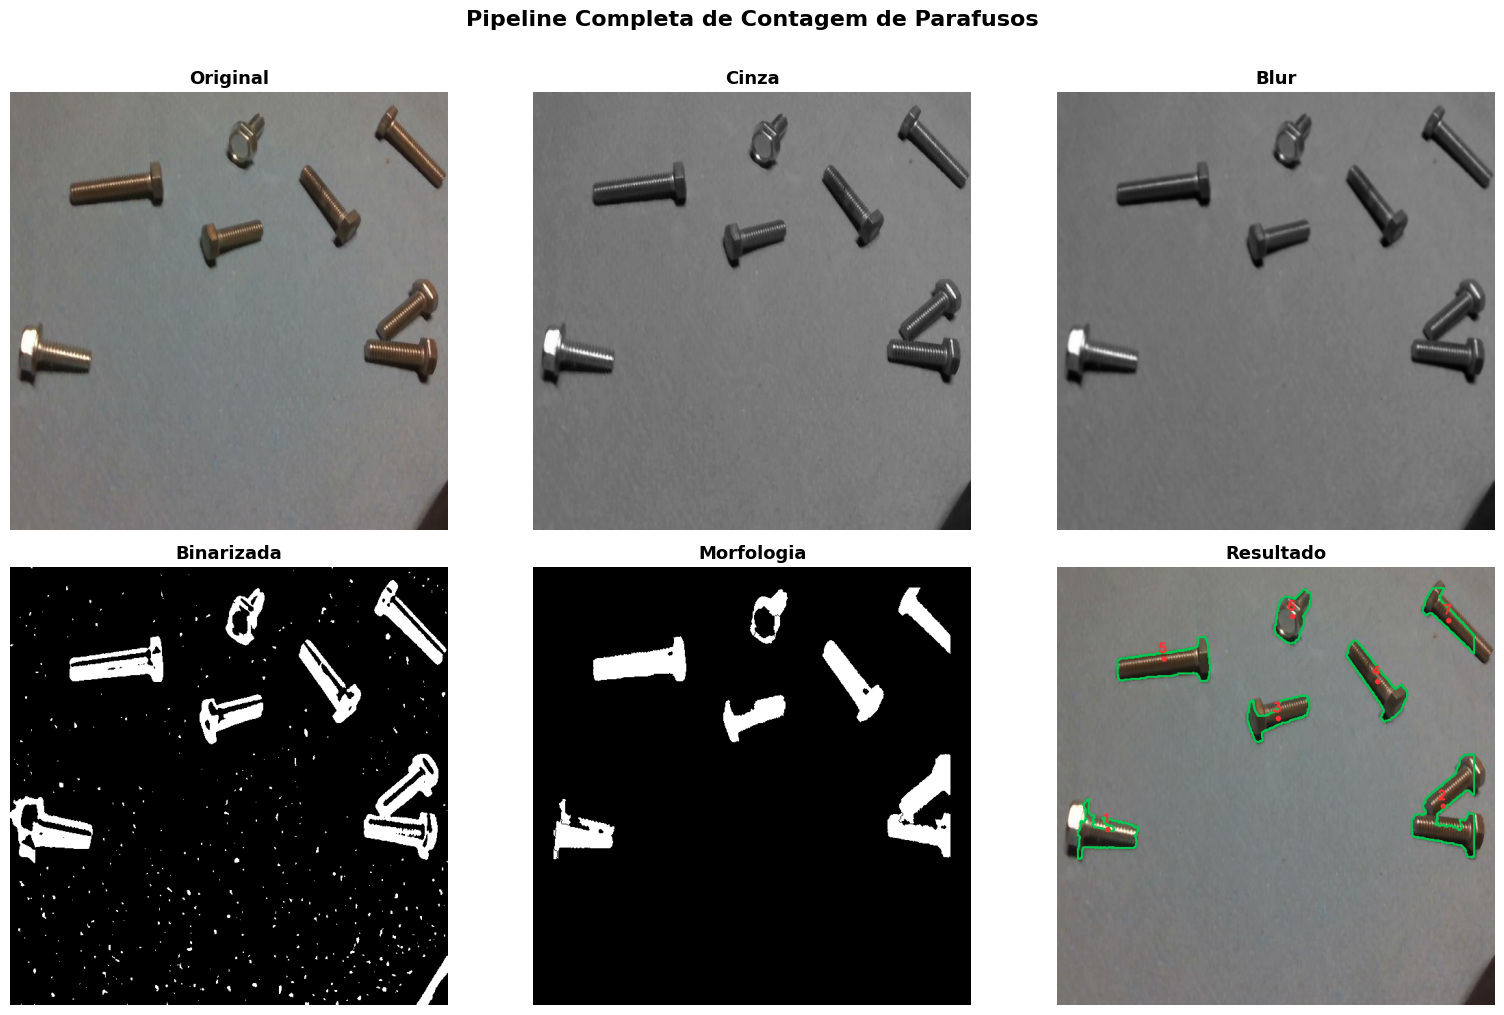

In [30]:
etapas = [
    ('Original',    imagem_rgb, None),
    ('Cinza',       cinza,      'gray'),
    ('Blur',        suavizada,  'gray'),
    ('Binarizada',  binaria,    'gray'),
    ('Morfologia',  limpa,      'gray'),
    ('Resultado',   vis_final,  None),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (titulo, img, cmap) in zip(axes.ravel(), etapas):
    ax.imshow(img, cmap=cmap)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Pipeline Completa de Contagem de Parafusos', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()